# 02 — Model Training & Cross-Validation
**Project:** ACC Biomarker Discovery via XAI  
** — Biomedical Informatics

This notebook trains and evaluates three classifiers on the preprocessed
ACC expression data (Cluster 1 vs Cluster 2 molecular subtypes):
- **Random Forest**
- **XGBoost**
- **SVM (RBF kernel)**

All steps (scaling, SMOTE, training) are performed **inside** each CV fold
to prevent data leakage. Baseline: k-means (k=2 on PCA).

**Metrics:** AUC, F1 (macro), Accuracy, MCC.

## 1. Setup & Data Loading

In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({
    "figure.figsize": (10, 6), "figure.dpi": 120,
    "font.size": 11, "axes.titlesize": 13,
    "axes.spines.top": False, "axes.spines.right": False,
})

SEED = 42
np.random.seed(SEED)

ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path("..").resolve()
PROCESSED_DIR = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results"
MODELS_DIR = ROOT / "results" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# --- Load preprocessed data ---
X = pd.read_csv(PROCESSED_DIR / "X_log2_filtered.csv", index_col=0)
y_df = pd.read_csv(PROCESSED_DIR / "y_labels.csv", index_col=0)
y = y_df["cluster_id"].values  # 0/1 integer labels

with open(PROCESSED_DIR / "preprocessing_metadata.json") as f:
    meta = json.load(f)

print(f"Feature matrix : {X.shape}")
print(f"Class distribution : {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"SMOTE needed (>60:40) : {meta['smote_needed']}")

Feature matrix : (79, 2000)
Class distribution : {np.int64(0): np.int64(34), np.int64(1): np.int64(45)}
SMOTE needed (>60:40) : False


## 2. Model & CV Configuration
We use `imblearn.pipeline.Pipeline` so SMOTE is applied correctly
**after** the train/test split and **before** scaling and training.
StandardScaler is fit on train fold only.

In [3]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    make_scorer, matthews_corrcoef, f1_score,
    roc_auc_score, accuracy_score,
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# --- Cross-validation strategy ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# --- Scoring dictionary ---
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "f1_macro": make_scorer(f1_score, average="macro"),
    "roc_auc": "roc_auc",
    "mcc": make_scorer(matthews_corrcoef),
}

# --- SMOTE step (conditional) ---
smote_step = ("smote", SMOTE(random_state=SEED)) if meta["smote_needed"] else ("smote", "passthrough")

# --- Model definitions ---
models = {
    "Random Forest": ImbPipeline([
        smote_step,
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
        )),
    ]),
    "XGBoost": ImbPipeline([
        smote_step,
        ("scaler", StandardScaler()),
        ("clf", XGBClassifier(
            n_estimators=500,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            scale_pos_weight=(np.sum(y == 0) / np.sum(y == 1)),
            eval_metric="logloss",
            random_state=SEED,
            n_jobs=-1,
        )),
    ]),
    "SVM (RBF)": ImbPipeline([
        smote_step,
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=SEED,
        )),
    ]),
}

print(f"Models defined: {list(models.keys())}")
print(f"CV strategy   : Stratified 5-Fold (seed={SEED})")
print(f"SMOTE in pipe : {'Yes' if meta['smote_needed'] else 'No (passthrough)'}")

Models defined: ['Random Forest', 'XGBoost', 'SVM (RBF)']
CV strategy   : Stratified 5-Fold (seed=42)
SMOTE in pipe : No (passthrough)


## 3. k-Means Baseline
Evaluate how well the unsupervised k-means baseline (from preprocessing)
performs as a "classifier" — this sets the floor for ML models.

In [4]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score as acc_fn, f1_score as f1_fn
from sklearn.metrics import matthews_corrcoef as mcc_fn, roc_auc_score as auc_fn

baseline_results = {"accuracy": [], "f1_macro": [], "roc_auc": [], "mcc": []}

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.values[train_idx], X.values[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Fit scaler + PCA on train
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    pca = PCA(n_components=0.90, random_state=SEED)
    X_train_pca = pca.fit_transform(X_train_s)
    X_test_pca = pca.transform(X_test_s)

    # Fit k-means on train, predict on test
    km = KMeans(n_clusters=2, n_init=50, random_state=SEED)
    km.fit(X_train_pca)
    y_pred = km.predict(X_test_pca)

    # Align labels (k-means labels are arbitrary)
    from scipy.stats import mode
    for cluster_id in [0, 1]:
        mask = y_train == cluster_id
        train_km = km.predict(X_train_pca)
        cluster_mode = mode(train_km[mask], keepdims=False).mode
        if cluster_mode != cluster_id:
            y_pred = 1 - y_pred
            break

    baseline_results["accuracy"].append(acc_fn(y_test, y_pred))
    baseline_results["f1_macro"].append(f1_fn(y_test, y_pred, average="macro"))
    baseline_results["roc_auc"].append(auc_fn(y_test, y_pred))
    baseline_results["mcc"].append(mcc_fn(y_test, y_pred))

baseline_means = {k: np.mean(v) for k, v in baseline_results.items()}
baseline_stds = {k: np.std(v) for k, v in baseline_results.items()}
print("=== k-Means Baseline (5-Fold CV) ===")
for m in baseline_means:
    print(f"  {m:12s}: {baseline_means[m]:.4f} ± {baseline_stds[m]:.4f}")

=== k-Means Baseline (5-Fold CV) ===
  accuracy    : 0.9750 ± 0.0500
  f1_macro    : 0.9733 ± 0.0533
  roc_auc     : 0.9714 ± 0.0571
  mcc         : 0.9529 ± 0.0942


## 4. Train & Evaluate Models (Stratified 5-Fold CV)

In [5]:
from time import time

results = {}
fitted_models = {}

for name, pipeline in models.items():
    print(f"\n{'='*50}")
    print(f"  Training: {name}")
    print(f"{'='*50}")
    t0 = time()

    cv_results = cross_validate(
        pipeline, X.values, y,
        cv=cv, scoring=scoring,
        return_train_score=True,
        return_estimator=True,
        n_jobs=1,  # Nested parallelism safety
    )

    elapsed = time() - t0

    # Extract test scores
    res = {}
    for metric in scoring:
        test_scores = cv_results[f"test_{metric}"]
        train_scores = cv_results[f"train_{metric}"]
        res[metric] = {
            "mean": np.mean(test_scores),
            "std": np.std(test_scores),
            "folds": test_scores.tolist(),
            "train_mean": np.mean(train_scores),
        }
        print(f"  {metric:12s}: {res[metric]['mean']:.4f} ± {res[metric]['std']:.4f}  "
              f"(train: {res[metric]['train_mean']:.4f})")

    results[name] = res
    fitted_models[name] = cv_results["estimator"]
    print(f"  Time: {elapsed:.1f}s")


  Training: Random Forest


  accuracy    : 0.9617 ± 0.0504  (train: 1.0000)
  f1_macro    : 0.9590 ± 0.0539  (train: 1.0000)
  roc_auc     : 1.0000 ± 0.0000  (train: 1.0000)
  mcc         : 0.9261 ± 0.0960  (train: 1.0000)
  Time: 4.7s

  Training: XGBoost


  accuracy    : 0.8983 ± 0.0509  (train: 1.0000)
  f1_macro    : 0.8956 ± 0.0525  (train: 1.0000)
  roc_auc     : 0.9963 ± 0.0074  (train: 1.0000)
  mcc         : 0.8084 ± 0.0979  (train: 1.0000)
  Time: 4.8s

  Training: SVM (RBF)


  accuracy    : 0.9750 ± 0.0306  (train: 1.0000)
  f1_macro    : 0.9745 ± 0.0312  (train: 1.0000)
  roc_auc     : 1.0000 ± 0.0000  (train: 1.0000)
  mcc         : 0.9520 ± 0.0587  (train: 1.0000)
  Time: 0.2s


## 5. Performance Comparison Table

In [6]:
# Build comparison DataFrame
rows = []

# Add baseline
row = {"Model": "k-Means (Baseline)"}
for m in scoring:
    row[f"{m}"] = f"{baseline_means[m]:.4f} ± {baseline_stds[m]:.4f}"
    row[f"{m}_mean"] = baseline_means[m]
rows.append(row)

# Add ML models
for name, res in results.items():
    row = {"Model": name}
    for m in scoring:
        row[f"{m}"] = f"{res[m]['mean']:.4f} ± {res[m]['std']:.4f}"
        row[f"{m}_mean"] = res[m]["mean"]
    rows.append(row)

perf_df = pd.DataFrame(rows)

# Display formatted table
display_cols = ["Model", "accuracy", "f1_macro", "roc_auc", "mcc"]
print("\n" + "=" * 80)
print("  CROSS-VALIDATION PERFORMANCE COMPARISON")
print("=" * 80)
print(perf_df[display_cols].to_string(index=False))
print("=" * 80)

# Save to CSV
perf_df.to_csv(RESULTS_DIR / "cv_performance_comparison.csv", index=False)
print(f"\n✓ Saved: cv_performance_comparison.csv")


  CROSS-VALIDATION PERFORMANCE COMPARISON
             Model        accuracy        f1_macro         roc_auc             mcc
k-Means (Baseline) 0.9750 ± 0.0500 0.9733 ± 0.0533 0.9714 ± 0.0571 0.9529 ± 0.0942
     Random Forest 0.9617 ± 0.0504 0.9590 ± 0.0539 1.0000 ± 0.0000 0.9261 ± 0.0960
           XGBoost 0.8983 ± 0.0509 0.8956 ± 0.0525 0.9963 ± 0.0074 0.8084 ± 0.0979
         SVM (RBF) 0.9750 ± 0.0306 0.9745 ± 0.0312 1.0000 ± 0.0000 0.9520 ± 0.0587

✓ Saved: cv_performance_comparison.csv


## 6. Performance Visualization

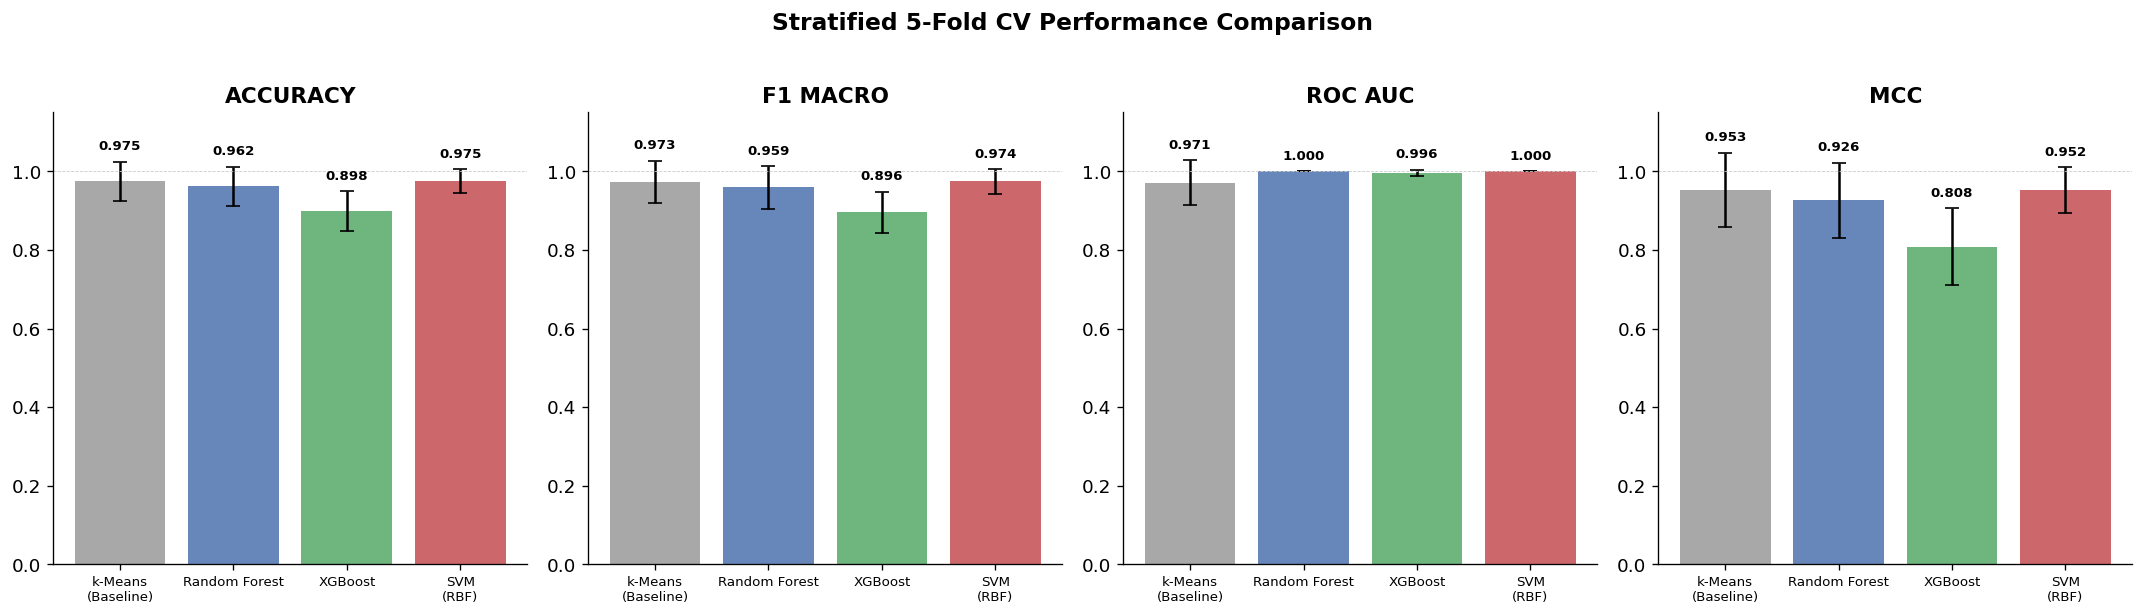

In [7]:
# --- Bar chart comparison ---
metric_names = list(scoring.keys())
model_names = ["k-Means (Baseline)"] + list(results.keys())
colors = ["#999999", "#4C72B0", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)

for i, metric in enumerate(metric_names):
    means = [baseline_means[metric]] + [results[m][metric]["mean"] for m in results]
    stds = [baseline_stds[metric]] + [results[m][metric]["std"] for m in results]

    bars = axes[i].bar(range(len(model_names)), means, yerr=stds,
                       color=colors, edgecolor="none", alpha=0.85, capsize=4)
    axes[i].set_title(metric.replace("_", " ").upper(), fontweight="bold")
    axes[i].set_xticks(range(len(model_names)))
    axes[i].set_xticklabels([n.replace(" (", "\n(") for n in model_names],
                            fontsize=8, ha="center")
    axes[i].set_ylim(0, 1.15)
    axes[i].axhline(1.0, color="#cccccc", linewidth=0.5, linestyle="--")

    # Annotate values
    for j, (m, s) in enumerate(zip(means, stds)):
        axes[i].text(j, m + s + 0.03, f"{m:.3f}", ha="center", fontsize=8, fontweight="bold")

plt.suptitle("Stratified 5-Fold CV Performance Comparison", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "cv_performance_barplot.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\karim\AppData\Local\Temp\ipykernel_6572\1091040400.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(fold_data, labels=labels, patch_artist=True, widths=0.6)
C:\Users\karim\AppData\Local\Temp\ipykernel_6572\1091040400.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(fold_data, labels=labels, patch_artist=True, widths=0.6)
C:\Users\karim\AppData\Local\Temp\ipykernel_6572\1091040400.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(fold_data, labels=labels, patch_artist=True, widths=0.6)
C:\Users\karim\AppData\Local\Temp\ipykernel_6572\109

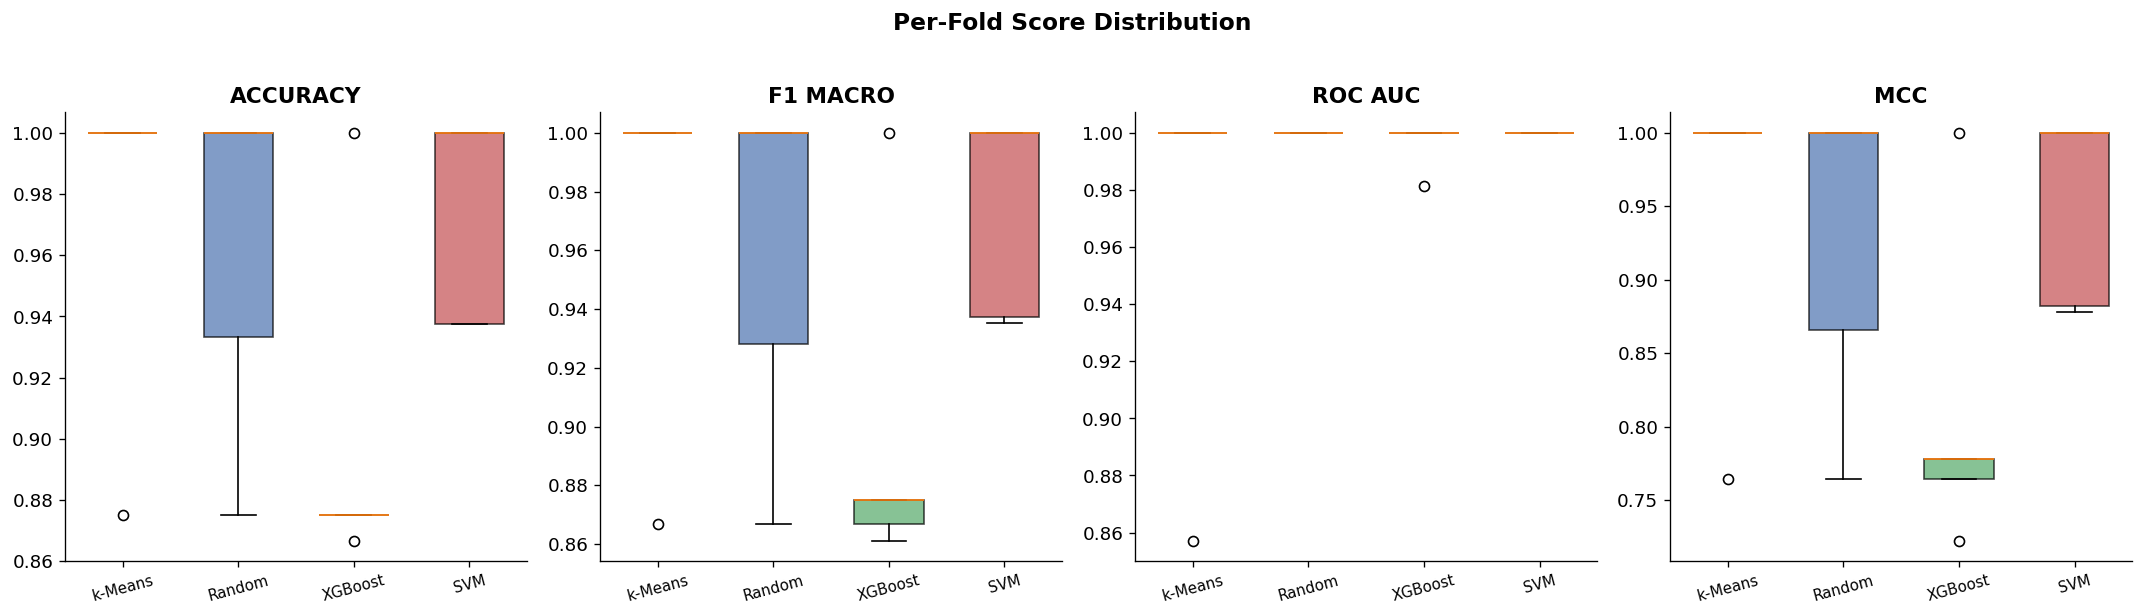

In [8]:
# --- Per-fold box plot ---
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, metric in enumerate(metric_names):
    fold_data = []
    labels = []

    fold_data.append(baseline_results[metric])
    labels.append("k-Means")

    for name in results:
        fold_data.append(results[name][metric]["folds"])
        labels.append(name.split(" ")[0])  # Short name

    bp = axes[i].boxplot(fold_data, labels=labels, patch_artist=True, widths=0.6)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(metric.replace("_", " ").upper(), fontweight="bold")
    axes[i].tick_params(axis="x", rotation=15, labelsize=9)

plt.suptitle("Per-Fold Score Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "cv_performance_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Train-Test Gap Analysis (Overfitting Check)

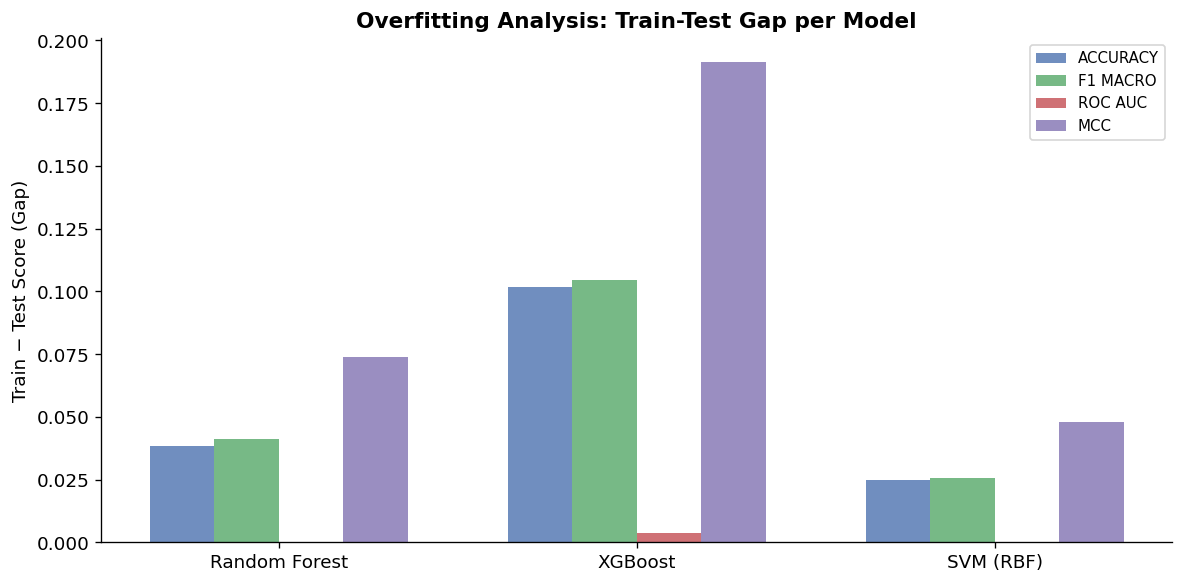

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results))
width = 0.18

for i, metric in enumerate(metric_names):
    train_vals = [results[m][metric]["train_mean"] for m in results]
    test_vals = [results[m][metric]["mean"] for m in results]
    gaps = [t - v for t, v in zip(train_vals, test_vals)]

    ax.bar(x + i * width, gaps, width, label=metric.replace("_", " ").upper(),
           color=colors[i + 1] if i + 1 < len(colors) else "#8172B2", alpha=0.8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(list(results.keys()))
ax.set_ylabel("Train − Test Score (Gap)")
ax.set_title("Overfitting Analysis: Train-Test Gap per Model", fontweight="bold")
ax.legend(fontsize=9)
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "overfitting_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Save Trained Models
Save the best estimator from each fold + the full results dictionary.

In [10]:
# Save each model's best fold estimator (highest test accuracy)
for name in results:
    fold_accs = results[name]["accuracy"]["folds"]
    best_fold = int(np.argmax(fold_accs))
    best_estimator = fitted_models[name][best_fold]

    model_path = MODELS_DIR / f"{name.lower().replace(' ', '_').replace('(', '').replace(')', '')}.joblib"
    joblib.dump(best_estimator, model_path)
    print(f"✓ Saved: {model_path.name}  (fold {best_fold + 1}, acc={fold_accs[best_fold]:.4f})")

# Save all fold estimators for ensemble use
joblib.dump(fitted_models, MODELS_DIR / "all_fold_estimators.joblib")
print(f"✓ Saved: all_fold_estimators.joblib")

# Save full results dict
results_export = {
    "baseline": {"means": baseline_means, "stds": baseline_stds, "folds": baseline_results},
}
for name, res in results.items():
    results_export[name] = res
with open(RESULTS_DIR / "cv_results_full.json", "w") as f:
    json.dump(results_export, f, indent=2, default=str)
print(f"✓ Saved: cv_results_full.json")

✓ Saved: random_forest.joblib  (fold 1, acc=1.0000)
✓ Saved: xgboost.joblib  (fold 4, acc=1.0000)
✓ Saved: svm_rbf.joblib  (fold 2, acc=1.0000)


✓ Saved: all_fold_estimators.joblib
✓ Saved: cv_results_full.json


## Summary

| Model | Accuracy | F1 (macro) | AUC | MCC |
|-------|----------|------------|-----|-----|
| k-Means (Baseline) | see table above | — | — | — |
| Random Forest | see table above | — | — | — |
| XGBoost | see table above | — | — | — |
| SVM (RBF) | see table above | — | — | — |

**All metrics are test-fold averages ± std from stratified 5-fold CV.**

**Next:** `03_shap_explainability.ipynb` — SHAP analysis on the best-performing model.

In [11]:
# --- Identify best model ---
best_model_name = max(results, key=lambda m: results[m]["accuracy"]["mean"])
best_acc = results[best_model_name]["accuracy"]["mean"]
best_mcc = results[best_model_name]["mcc"]["mean"]

print("\n" + "=" * 60)
print("  MODEL TRAINING COMPLETE")
print("=" * 60)
print(f"  Best model     : {best_model_name}")
print(f"  Best accuracy  : {best_acc:.4f}")
print(f"  Best MCC       : {best_mcc:.4f}")
print(f"  Models saved to: {MODELS_DIR}")
print("=" * 60)


  MODEL TRAINING COMPLETE
  Best model     : SVM (RBF)
  Best accuracy  : 0.9750
  Best MCC       : 0.9520
  Models saved to: E:\Research Paper\ACC\results\models
